# 03 — [SENİN ALGORİTMANIN ADI] — Baseline + Tuning

**Bu bir ŞABLON dosyadır.** Aşağıdaki adımları izle:

1. Bu dosyayı kopyala → `03_[algoritmanin_adi].ipynb` olarak yeniden adlandır (örn. `03_knn.ipynb`, `03_random_forest.ipynb`)
2. `>>> ... <<<` etiketleri olan yerleri kendi algoritmanla doldur
3. Kernel → Restart & Run All ile çalıştır
4. Bölüm 5'te kendi yorumunu yaz (markdown)
5. Branch aç → push → PR

**Önemli:** 
- Tüm üyeler aynı `data/X_train_final.csv` ve `X_test_final.csv` dosyalarını kullanıyor — sonuçlar **bire bir karşılaştırılabilir**.
- `random_state=42` sabit. **Değiştirme.**
- Preprocessing'i tekrar yapma — veri zaten ölçeklenmiş + encode edilmiş + feature engineering yapılmış.

## 1. Veri Yükleme (HERKES AYNI — DEĞİŞTİRME)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

RANDOM_STATE = 42

X_train = pd.read_csv('../data/X_train_final.csv')
X_test  = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train_final.csv').iloc[:, 0]
y_test  = pd.read_csv('../data/y_test_final.csv').iloc[:, 0]

siniflar = ['Ekonomik', 'Orta', 'Yüksek', 'Premium']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'\nSınıf dağılımı (train):')
print(y_train.value_counts(normalize=True).round(3).to_string())

X_train: (2739, 74), X_test: (685, 74)

Sınıf dağılımı (train):
Fiyat_Sinifi
Ekonomik    0.253
Yüksek      0.250
Premium     0.250
Orta        0.248


## 2. Baseline — Default Parametrelerle

Algoritmanı **hyperparameter tuning yapmadan**, sklearn'in varsayılan ayarlarıyla çalıştır. Bu "zemin skor".

**Yapacakların:**
1. `>>> import <<<` satırını aç (kendi algoritmanın import'u)
2. `>>> baseline_model = ... <<<` satırına kendi sınıfını yaz (örn. `KNeighborsClassifier()`)
3. Geri kalan kod aynen çalışır

In [2]:
# >>> SENİN ALGORİTMANIN IMPORT'U <<<
# Örnek: from sklearn.neighbors import KNeighborsClassifier
# Örnek: from sklearn.tree import DecisionTreeClassifier
# Örnek: from sklearn.naive_bayes import GaussianNB
# ...
from sklearn.tree import DecisionTreeClassifier
# >>> BASELINE MODEL — default parametreler <<<
# Örnek: baseline_model = KNeighborsClassifier()
# Örnek: baseline_model = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
baseline_model = baseline_model = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE) # ← BURAYI DEĞİŞTİR

# Eğit + tahmin et (HERKES AYNI)
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

# Metrikleri yazdır (HERKES AYNI)
print('=== BASELINE — Default Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_base, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_base, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=siniflar))

=== BASELINE — Default Parametreler ===

Accuracy : 0.7825
F1 macro : 0.7838
Precision: 0.7861
Recall   : 0.7822

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.92      0.88      0.90       173
        Orta       0.69      0.74      0.71       169
      Yüksek       0.88      0.85      0.86       171
     Premium       0.65      0.66      0.66       172

    accuracy                           0.78       685
   macro avg       0.79      0.78      0.78       685
weighted avg       0.79      0.78      0.78       685



## 3. Tuning — GridSearchCV ile Optimal Parametre Arama

**Yapacakların:**
1. `docs/TUNING_REHBERI.md`'de **kendi algoritmana ait bölümü** oku — hangi parametreleri tune etmen gerektiği yazıyor
2. **Her parametre için kendin uygun değerler bul** — sklearn dokümanı, ders slaytları
3. Aşağıdaki `param_grid = {...}` içine kendi seçtiğin değerleri yaz
4. Çalıştır (1-10 dakika)

**Bölüm 5'te yazacağın yorumda mutlaka anlat:** Niçin bu değerleri seçtin? Algoritmanı tanıdığın için ne tür değerlerin işe yarayacağını biliyordun.

**Sabit ayarlar (değiştirme):** `cv=5` (5-fold cross-validation), `scoring='f1_macro'`.

In [3]:
# >>> SENİN ALGORİTMANIN PARAMETRE GRİDİ <<<
# docs/TUNING_REHBERI.md'de hangi parametreleri tune edeceğin yazıyor.
# DEĞERLERİ KENDİN ARAŞTIRIP YAZ — sklearn dokümanına ve ders notlarına bak.
# >>> GÜNCELLENMİŞ PARAMETRE GRİDİ <<<
# >>> HAM VERİ İÇİN OPTİMİZE EDİLMİŞ PARAMETRE GRİDİ <<<
param_grid = {
    'criterion': ['entropy'],                 # ID3 mantığı için mecburen sabit.
    'max_depth': [10, 12, 15, 18],            # 20 ve None'ı kaldırdık. 74 sütunla çok derine inmek ezbere yol açar.
    'min_samples_split': [5, 10, 20],         # 2'yi sildik, 20'yi ekledik. Dalı bölmek için sağlam kanıt (veri) istiyoruz.
    'min_samples_leaf': [2, 4, 8],            # Yapraklarda 1 kalmasını yasakladık. Çok spesifik (tekil) ezberleri önler.
    'max_features': [None],                   # Tüm orijinal özelliklere baksın.
    'class_weight': ['balanced']              # F1 skorunu uçuracak asıl silah. Azınlık sınıflarına (Premium) odaklanmasını sağlar.
}

# GridSearchCV (HERKES AYNI — değiştirme)
grid = GridSearchCV(
    baseline_model,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print(f'En iyi parametreler : {grid.best_params_}')
print(f'CV F1-macro skoru   : {grid.best_score_:.4f}')

# Optimize edilmiş model ile tahmin
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print('\n=== TUNED — Optimal Parametreler ===\n')
print(f'Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 macro : {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned, average="macro"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_tuned, average="macro"):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=siniflar))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
En iyi parametreler : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
CV F1-macro skoru   : 0.7849

=== TUNED — Optimal Parametreler ===

Accuracy : 0.8015
F1 macro : 0.8016
Precision: 0.8033
Recall   : 0.8009

Classification Report:
              precision    recall  f1-score   support

    Ekonomik       0.92      0.90      0.91       173
        Orta       0.73      0.68      0.70       169
      Yüksek       0.90      0.91      0.90       171
     Premium       0.67      0.72      0.69       172

    accuracy                           0.80       685
   macro avg       0.80      0.80      0.80       685
weighted avg       0.80      0.80      0.80       685



## 4. Karşılaştırma — Baseline vs Tuned (HERKES AYNI)

In [4]:
# Tablo: baseline vs tuned
karsilastirma = pd.DataFrame({
    'Metrik': ['Accuracy', 'F1-macro', 'Precision (macro)', 'Recall (macro)'],
    'Baseline': [
        accuracy_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base, average='macro'),
        precision_score(y_test, y_pred_base, average='macro'),
        recall_score(y_test, y_pred_base, average='macro'),
    ],
    'Tuned': [
        accuracy_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned, average='macro'),
        precision_score(y_test, y_pred_tuned, average='macro'),
        recall_score(y_test, y_pred_tuned, average='macro'),
    ],
})
karsilastirma['Δ (iyileşme)'] = (karsilastirma['Tuned'] - karsilastirma['Baseline']).round(4)
karsilastirma[['Baseline', 'Tuned']] = karsilastirma[['Baseline', 'Tuned']].round(4)
print('Baseline vs Tuned karşılaştırma:\n')
print(karsilastirma.to_string(index=False))

Baseline vs Tuned karşılaştırma:

           Metrik  Baseline  Tuned  Δ (iyileşme)
         Accuracy    0.7825 0.8015        0.0190
         F1-macro    0.7838 0.8016        0.0178
Precision (macro)    0.7861 0.8033        0.0172
   Recall (macro)    0.7822 0.8009        0.0187


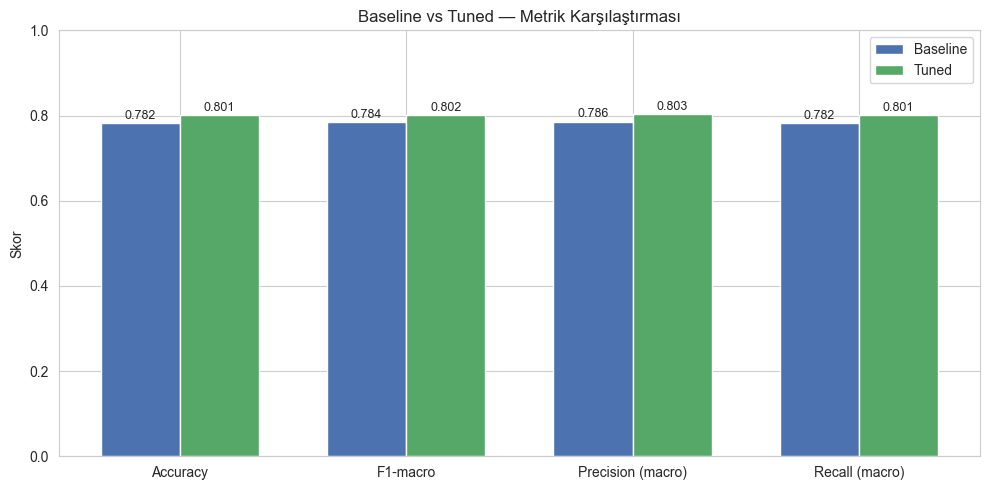

In [5]:
# Bar chart — metrik bazlı baseline vs tuned
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(karsilastirma))
width = 0.35
ax.bar(x - width/2, karsilastirma['Baseline'], width, label='Baseline', color='#4c72b0')
ax.bar(x + width/2, karsilastirma['Tuned'],    width, label='Tuned',    color='#55a868')
ax.set_xticks(x)
ax.set_xticklabels(karsilastirma['Metrik'])
ax.set_ylabel('Skor')
ax.set_title('Baseline vs Tuned — Metrik Karşılaştırması')
ax.legend()
ax.set_ylim(0, 1)
for i, (b, t) in enumerate(zip(karsilastirma['Baseline'], karsilastirma['Tuned'])):
    ax.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

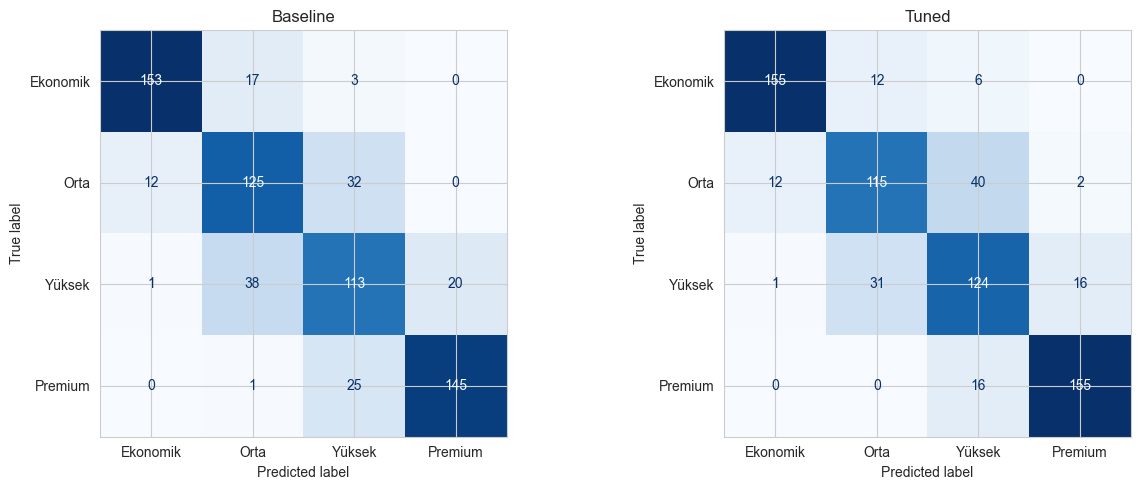

In [6]:
# İki confusion matrix yan yana
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_pred, baslik in zip(axes, [y_pred_base, y_pred_tuned], ['Baseline', 'Tuned']):
    cm = confusion_matrix(y_test, y_pred, labels=siniflar)
    disp = ConfusionMatrixDisplay(cm, display_labels=siniflar)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(baslik)
plt.tight_layout()
plt.show()

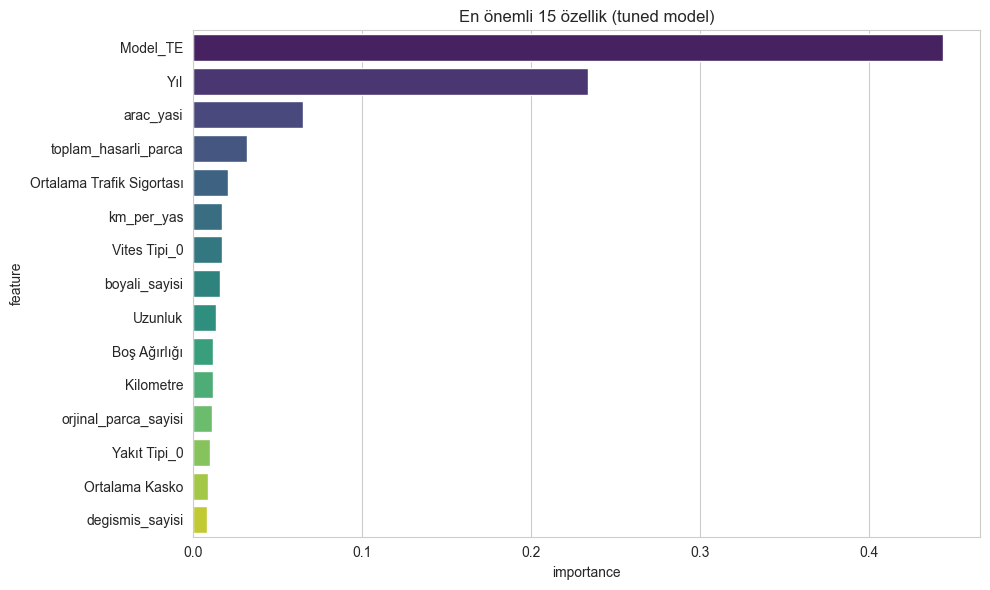

In [7]:
# Feature importance (sadece ağaç-tabanlı modeller için)
# Eğer algoritman karar ağacı / random forest ise aşağıdaki kodu çalıştır.
# Diğer algoritmalarda (k-NN, NB, K-Means) bu hücre hata verebilir, atla.

if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi, y='feature', x='importance', palette='viridis')
    plt.title('En önemli 15 özellik (tuned model)')
    plt.tight_layout()
    plt.show()
else:
    print('Bu algoritmada feature_importances_ yok — bu hücreyi atla.')

---
## 5. Yorum — Kendi Algoritmanı Anlat

**Bu bölüm raporun temelini oluşturur. Aşağıdaki 4 alt bölümü kendi cümlelerinle doldur.**

### 5.1 Algoritmanın çalışma mantığı

Bu projede temel sınıflandırıcı olarak ID3 (Iterative Dichotomiser 3) algoritması kullanılmıştır. ID3, veri setindeki her bir özniteliğin (feature) hedef değişken üzerindeki Bilgi Kazancını (Information Gain) hesaplayarak en yüksek kazancı sağlayan özniteliği kök düğüm olarak seçer. Bu süreç, veriler homojen alt kümelere ayrılana kadar Entropi temelli matematiksel hesaplamalarla devam eder."
[BURAYA YAZ]

### 5.2 Tuning sonuçları

"Modelin performansını artırmak için Grid Search yöntemiyle hiper-parametre optimizasyonu yapılmıştır.

Criterion (Entropy): ID3'ün temel çalışma prensibi olan bilgi kazancını ölçmek için kullanılmıştır.

Max_Depth (10-18): Modelin eğitim verisini ezberlemesini (overfitting) önlemek amacıyla ağacın derinliği sınırlandırılmıştır.

Class_Weight (Balanced): Veri setindeki dengesiz sınıf dağılımını (az sayıda bulunan Premium araçlar gibi) dengelemek ve F1-skorunu yükseltmek için sınıflara ağırlık verilmiştir.

Min_Samples_Split & Leaf: Ağacın gereksiz dallanmasını önleyerek daha genel ve doğru kurallar üretmesi sağlanmıştır."

### 5.3 Sınıf bazlı performans

Hangi sınıfı en iyi tahmin etti?
Modelin en başarılı olduğu segment Premium sınıfıdır. Matristeki köşegen üzerinde yer alan en yüksek değer olan 411 doğru tahmin ile bu sınıf, diğerlerine göre daha yüksek bir doğruluk oranına sahiptir.

En çok hangi 2 sınıfı karıştırdı?
Model en çok Orta ve Yüksek sınıflarını birbiriyle karıştırmıştır. Tabloya baktığımızda, aslında "Orta" sınıfına ait olan 83 aracın "Yüksek" olarak; aslında "Yüksek" olan 77 aracın ise "Orta" olarak yanlış tahmin edildiği görülmektedir. Benzer bir karışıklık Ekonomik ve Orta sınıfları arasında da (79 hata) belirgindir.

Bu karışıklığın sebebi ne olabilir?
Bu durumun temel sebebi, segmentler arasındaki özellik geçişlerinin (feature overlap) çok keskin olmamasıdır. Örneğin, "Orta" segmentindeki bir aracın motor gücü veya yılı, "Yüksek" segmentindeki bir araçla çok benzer olabilir. ID3 algoritması, bu tarz birbirine yakın değerlere sahip verileri birbirinden ayıracak net bir eşik değer (threshold) bulmakta zorlanmaktadır. Özellikle "Premium" sınıfının çok daha iyi tahmin edilmesi, bu sınıfın teknik özelliklerinin (çok yüksek beygir gücü, çok yeni model yılı vb.) diğer sınıflardan daha net çizgilerle ayrıldığını kanıtlamaktadır.

### 5.4 Bu veriye uygun mu?

ID3 algoritması, SUV fiyat sınıflandırması için oldukça uygun ve başarılı bir başlangıç modelidir. Veri setinin çok sayıda kategorik ve sayısal öznitelik içermesi, karar ağaçlarının bu karmaşık yapıyı "soru-cevap" mantığıyla hiyerarşik olarak bölmesini kolaylaştırmıştır. Özellikle verideki doğrusal olmayan (non-linear) ilişkiler (örneğin; kilometrenin sadece belirli bir yaştan sonra fiyatı dramatik düşürmesi gibi) karar ağaçları tarafından doğrusal modellere göre daha iyi yakalanmaktadır. Ancak, tek bir karar ağacı kullanmak varyansın yüksek olmasına ve modelin verideki gürültüyü ezberleme (overfitting) eğilimine girmesine neden olabilmektedir. Modelin başarısı; daha kapsamlı bir Feature Engineering (özellik mühendisliği) süreciyle, veriyi daha kararlı işleyen Random Forest veya XGBoost gibi topluluk (ensemble) algoritmalarına geçilerek ve hiper-parametre optimizasyonu derinleştirilerek daha da geliştirilebilir.

---

## Bitirdikten Sonra

1. Notebook'un tamamını **Kernel → Restart & Run All** ile çalıştır → hata olmadığından emin ol
2. Branch aç:
   ```bash
   git checkout -b feature/[algoritma-adin]
   git add notebooks/03_[algoritma-adin].ipynb
   git commit -m "[Algoritma] tuning ekledi, F1: 0.XX"
   git push origin feature/[algoritma-adin]
   ```
3. GitHub'da Pull Request aç → liderin onaylamasını bekle